# Phase 2 — Ensemble ML Model
## FIFA 21 Player Position Classification
> ต้องรัน `01_eda_preprocessing.ipynb` ก่อน เพื่อให้มีไฟล์ `fifa21_splits.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
os.makedirs('../models', exist_ok=True)
os.makedirs('../app/static/images', exist_ok=True)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# โหลด Splits จาก Phase 1
splits = joblib.load('../data/processed/fifa21_splits.pkl')
X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']
y_train, y_val, y_test = splits['y_train'], splits['y_val'], splits['y_test']
feature_cols = splits['feature_cols']
le = splits['label_encoder']

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'Classes: {le.classes_}')
print(f'Features: {feature_cols}')

Train : (13285, 15)
Val   : (2847, 15)
Test  : (2847, 15)
Classes: ['DEF' 'FWD' 'GK' 'MID']
Features: ['Age', 'POT', 'Height', 'Weight', 'Value', 'Wage', 'W/F', 'SM', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']


In [3]:
# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print('Scaling complete ✓')

Scaling complete ✓


### 🌲 Model 1 — Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
rf_val_pred = rf.predict(X_val_sc)
print(f'Random Forest Val  Accuracy: {accuracy_score(y_val, rf_val_pred):.4f}')
print(f'Random Forest Val  F1-Score: {f1_score(y_val, rf_val_pred, average="weighted"):.4f}')

Random Forest Val  Accuracy: 0.8918
Random Forest Val  F1-Score: 0.8917


### ⚡ Model 2 — XGBoost

In [5]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=50
)
xgb_val_pred = xgb_model.predict(X_val_sc)
print(f'\nXGBoost Val  Accuracy: {accuracy_score(y_val, xgb_val_pred):.4f}')
print(f'XGBoost Val  F1-Score: {f1_score(y_val, xgb_val_pred, average="weighted"):.4f}')

[0]	validation_0-mlogloss:1.16710
[50]	validation_0-mlogloss:0.27186
[100]	validation_0-mlogloss:0.24254
[150]	validation_0-mlogloss:0.23601
[200]	validation_0-mlogloss:0.23603
[250]	validation_0-mlogloss:0.23851
[299]	validation_0-mlogloss:0.24252

XGBoost Val  Accuracy: 0.8974
XGBoost Val  F1-Score: 0.8972


### 🚀 Model 3 — LightGBM

In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)]
)
lgb_val_pred = lgb_model.predict(X_val_sc)
print(f'LightGBM Val  Accuracy: {accuracy_score(y_val, lgb_val_pred):.4f}')
print(f'LightGBM Val  F1-Score: {f1_score(y_val, lgb_val_pred, average="weighted"):.4f}')

LightGBM Val  Accuracy: 0.8967
LightGBM Val  F1-Score: 0.8966


### 🔧 Hyperparameter Tuning — GridSearchCV (Random Forest)

In [7]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)
rf_grid.fit(X_train_sc, y_train)
print(f'Best RF Params: {rf_grid.best_params_}')
print(f'Best RF CV F1: {rf_grid.best_score_:.4f}')
# ใช้ best RF
rf_best = rf_grid.best_estimator_

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best RF Params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Best RF CV F1: 0.8877


### 🏆 Model 4 — Stacking Classifier (Meta Learner = Logistic Regression)

In [8]:
estimators = [
    ('rf',  RandomForestClassifier(**rf_grid.best_params_, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8, eval_metric='mlogloss',
                               random_state=42, n_jobs=-1)),
    ('lgb', lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, verbose=-1, n_jobs=-1))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=1
)
stacking_clf.fit(X_train_sc, y_train)
stack_val_pred = stacking_clf.predict(X_val_sc)
print(f'\nStacking Val  Accuracy: {accuracy_score(y_val, stack_val_pred):.4f}')
print(f'Stacking Val  F1-Score: {f1_score(y_val, stack_val_pred, average="weighted"):.4f}')


Stacking Val  Accuracy: 0.8925
Stacking Val  F1-Score: 0.8924


### 📊 Test Set Evaluation & Model Comparison

In [9]:
def evaluate_model(name, model, X, y_true, classes):
    y_pred = model.predict(X)
    metrics = {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, average='weighted'), 4)
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_true, y_pred, target_names=classes))
    return metrics

results = []
models_to_eval = [
    ('Random Forest',      rf_best),
    ('XGBoost',            xgb_model),
    ('LightGBM',           lgb_model),
    ('Stacking Classifier', stacking_clf)
]
for name, model in models_to_eval:
    results.append(evaluate_model(name, model, X_test_sc, y_test, le.classes_))

results_df = pd.DataFrame(results)
print('\n=== Model Comparison (Test Set) ===')
print(results_df.to_string(index=False))


=== Random Forest ===
              precision    recall  f1-score   support

         DEF       0.91      0.90      0.90       959
         FWD       0.91      0.81      0.86       486
          GK       1.00      1.00      1.00       311
         MID       0.84      0.88      0.86      1091

    accuracy                           0.89      2847
   macro avg       0.91      0.90      0.90      2847
weighted avg       0.89      0.89      0.89      2847


=== XGBoost ===
              precision    recall  f1-score   support

         DEF       0.91      0.91      0.91       959
         FWD       0.89      0.84      0.86       486
          GK       1.00      1.00      1.00       311
         MID       0.86      0.88      0.87      1091

    accuracy                           0.90      2847
   macro avg       0.92      0.91      0.91      2847
weighted avg       0.90      0.90      0.90      2847


=== LightGBM ===
              precision    recall  f1-score   support

         DEF     

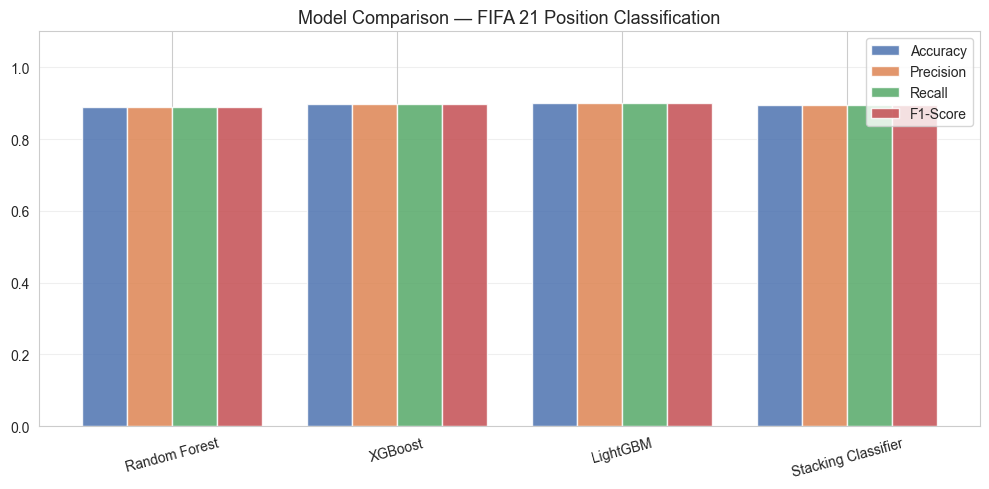

In [10]:
# Bar Chart เปรียบเทียบ
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — FIFA 21 Position Classification', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../app/static/images/ml_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

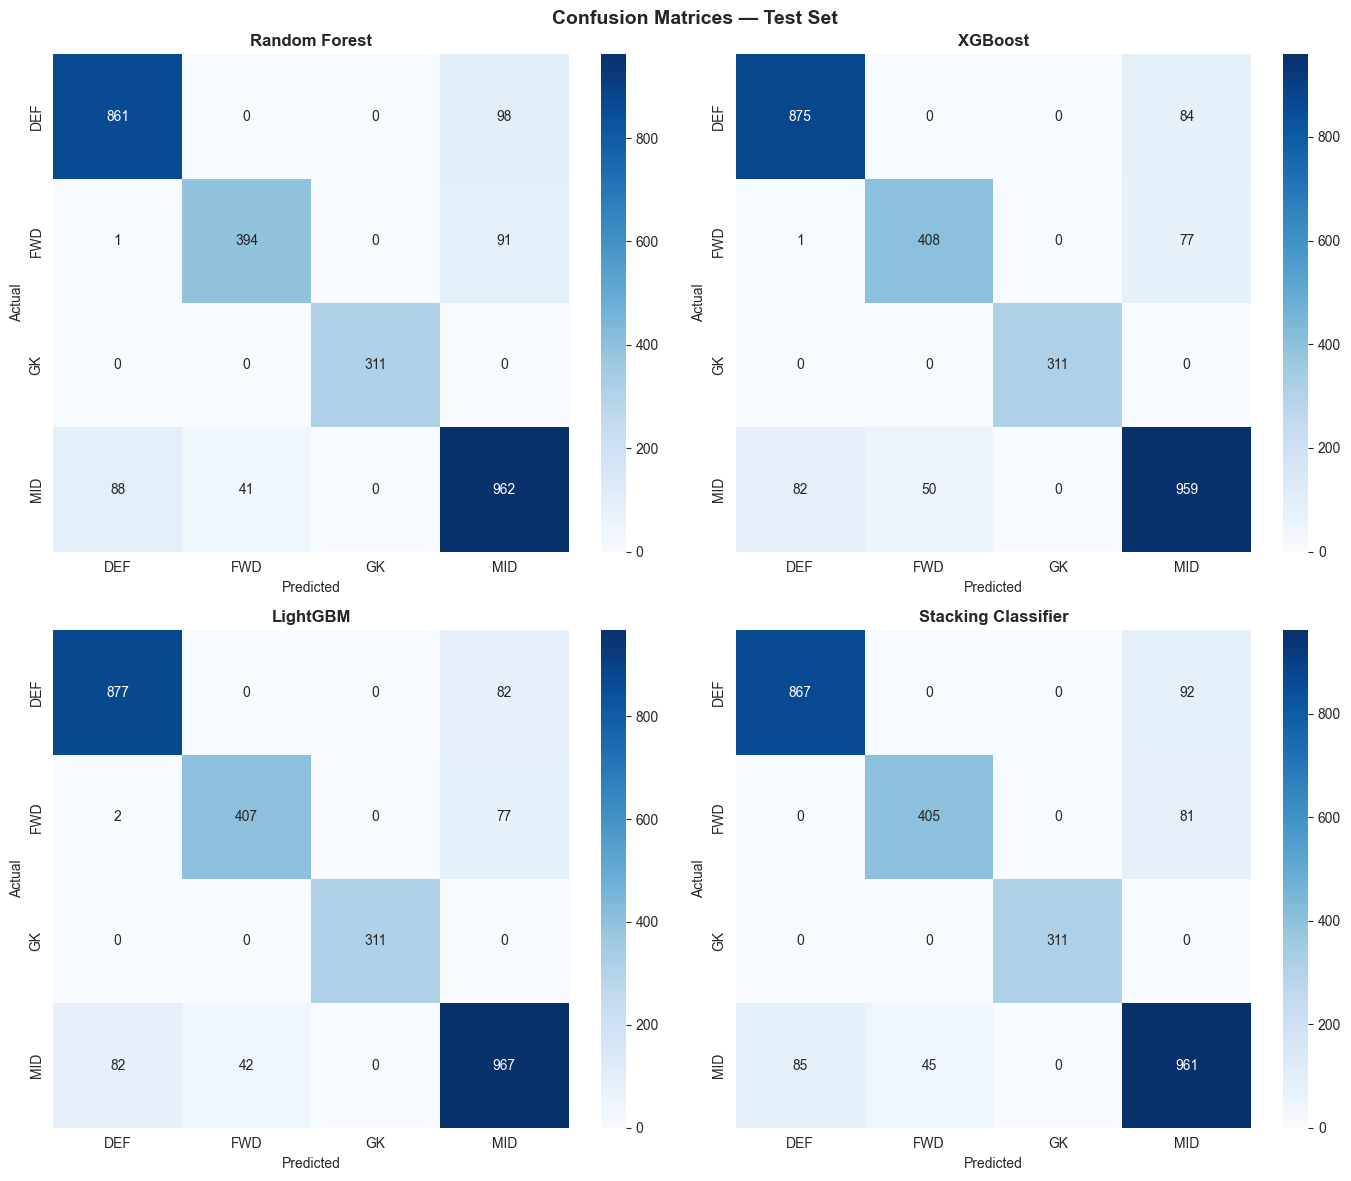

In [11]:
# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, model) in zip(axes.flatten(), models_to_eval):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../app/static/images/ml_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

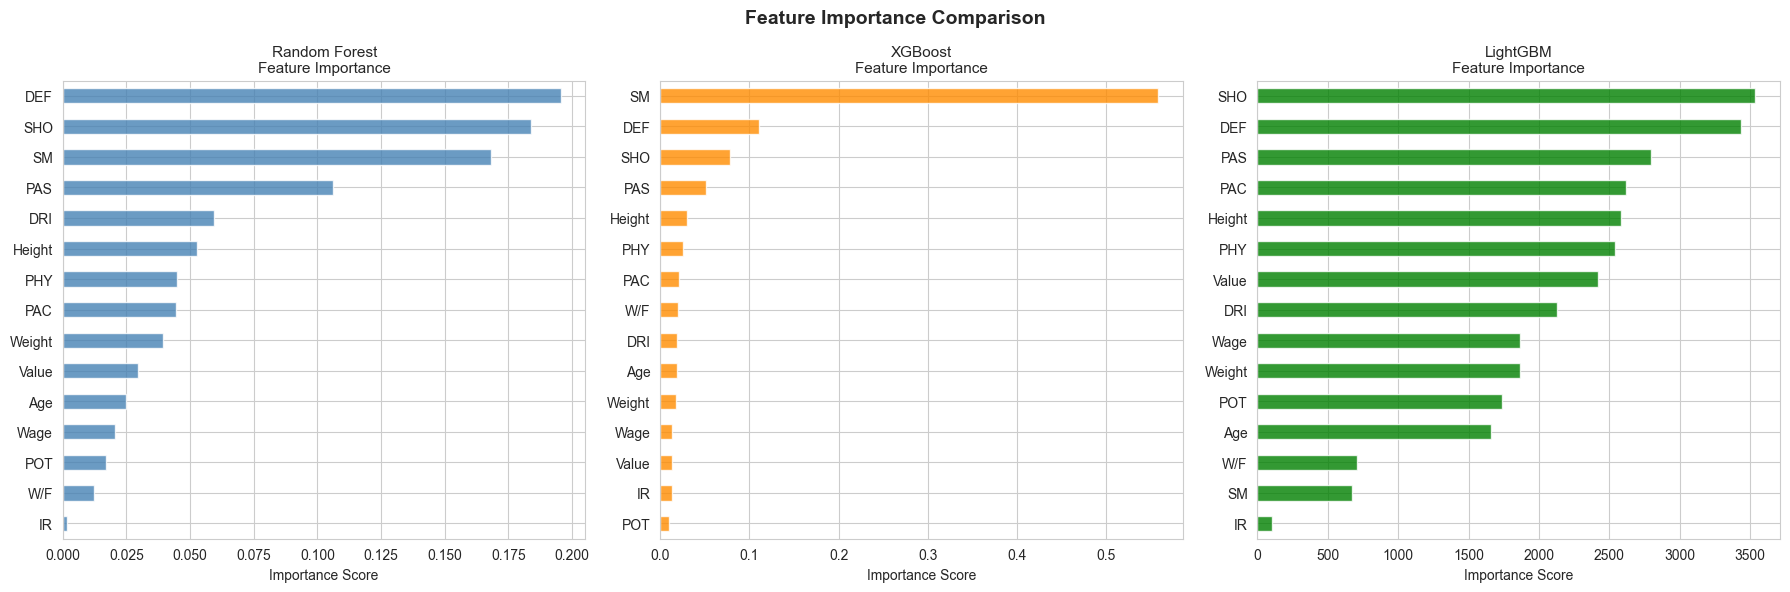

In [12]:
# Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
importance_models = [
    ('Random Forest', rf_best, rf_best.feature_importances_),
    ('XGBoost',       xgb_model, xgb_model.feature_importances_),
    ('LightGBM',      lgb_model, lgb_model.feature_importances_)
]
colors = ['steelblue', 'darkorange', 'green']
for ax, (name, _, imp), color in zip(axes, importance_models, colors):
    feat_series = pd.Series(imp, index=feature_cols).sort_values(ascending=True)
    feat_series.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(f'{name}\nFeature Importance', fontsize=11)
    ax.set_xlabel('Importance Score')
plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../app/static/images/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# บันทึก Models
joblib.dump(stacking_clf, '../models/ensemble_model.pkl')
joblib.dump(scaler,       '../models/scaler.pkl')
joblib.dump({
    'feature_cols': feature_cols,
    'classes': le.classes_.tolist()
}, '../models/ml_metadata.pkl')

print('✓ Saved: ensemble_model.pkl')
print('✓ Saved: scaler.pkl')
print('✓ Saved: ml_metadata.pkl')

# บันทึก results summary
results_df.to_csv('../data/processed/ml_results.csv', index=False)
print('✓ Saved: ml_results.csv')
print('\n=== Phase 2 Complete! ===')

✓ Saved: ensemble_model.pkl
✓ Saved: scaler.pkl
✓ Saved: ml_metadata.pkl
✓ Saved: ml_results.csv

=== Phase 2 Complete! ===
